In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_squared_error
from sklearn.pipeline import Pipeline

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [2]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['species'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print("Первые 5 строк датасета:")
display(df.head())

print(f"\nРазмер датасета: {df.shape}")
print(f"Статистическое описание данных:")
display(df.describe())

print(f"\nРаспределение классов:")
print(df['species'].value_counts())

Первые 5 строк датасета:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa



Размер датасета: (150, 6)
Статистическое описание данных:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000



Распределение классов:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


<Figure size 1200x1000 with 0 Axes>

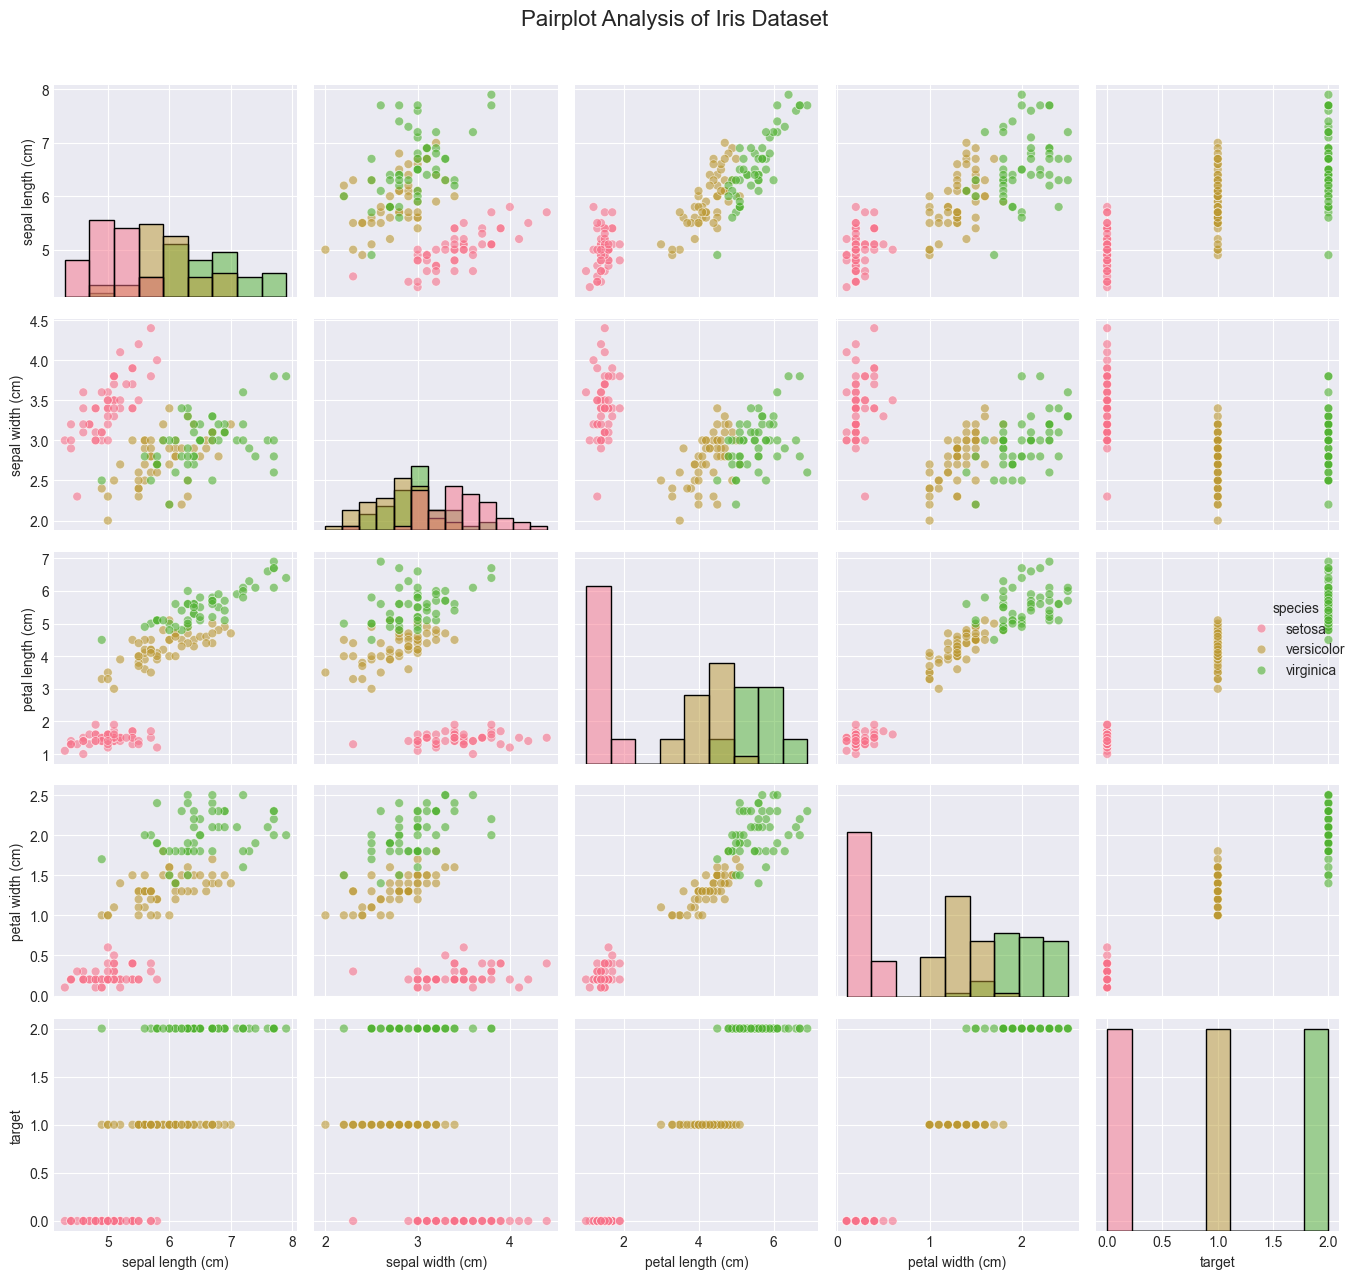

In [3]:
plt.figure(figsize=(12, 10))
pairplot = sns.pairplot(df, hue='species', diag_kind='hist', 
                        plot_kws={'alpha': 0.6, 's': 40},
                        diag_kws={'alpha': 0.5})
pairplot.fig.suptitle("Pairplot Analysis of Iris Dataset", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# Классификация Setosa vs Non-Setosa
df_binary = df.copy()
df_binary['binary_target'] = (df_binary['target'] == 0).astype(int)

print("Распределение бинарных классов:")
print(df_binary['binary_target'].value_counts())

# Подготовка данных
X = df_binary[iris.feature_names].values
y = df_binary['binary_target'].values

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, 
                                                    random_state=42, 
                                                    stratify=y)

# Создание pipeline с масштабированием и логистической регрессией
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(random_state=42, max_iter=1000))
])

# Обучение модели
pipeline.fit(X_train, y_train)

# Предсказания
y_train_pred = pipeline.predict(X_train)
y_test_pred = pipeline.predict(X_test)

# Оценка качества
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Результаты бинарной классификации (Setosa vs Non-Setosa):")
print(f"Точность на обучающей выборке: {train_accuracy:.4f}")
print(f"Точность на тестовой выборке: {test_accuracy:.4f}")

print("\nClassification Report на тестовой выборке:")
print(classification_report(y_test, y_test_pred, 
                          target_names=['Non-Setosa', 'Setosa']))

Распределение бинарных классов:
binary_target
0    100
1     50
Name: count, dtype: int64
Результаты бинарной классификации (Setosa vs Non-Setosa):
Точность на обучающей выборке: 1.0000
Точность на тестовой выборке: 1.0000

Classification Report на тестовой выборке:
              precision    recall  f1-score   support

  Non-Setosa       1.00      1.00      1.00        30
      Setosa       1.00      1.00      1.00        15

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



Степень  1: Train MSE = 0.9474, Test MSE = 0.8825
Степень  2: Train MSE = 0.9429, Test MSE = 0.8422
Степень  3: Train MSE = 0.2217, Test MSE = 0.1616
Степень  4: Train MSE = 0.2120, Test MSE = 0.1799
Степень  5: Train MSE = 0.2072, Test MSE = 0.1736
Степень  6: Train MSE = 0.2071, Test MSE = 0.1717
Степень  8: Train MSE = 0.2043, Test MSE = 0.2151
Степень 10: Train MSE = 0.2033, Test MSE = 0.2484
Степень 15: Train MSE = 0.1939, Test MSE = 0.9872


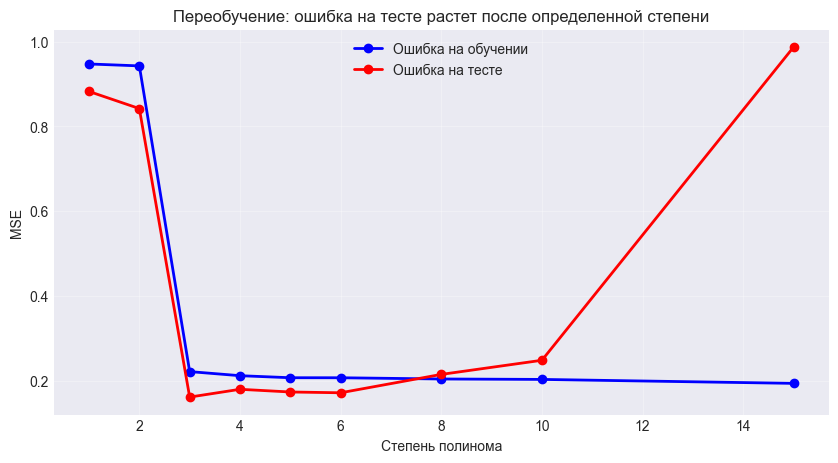

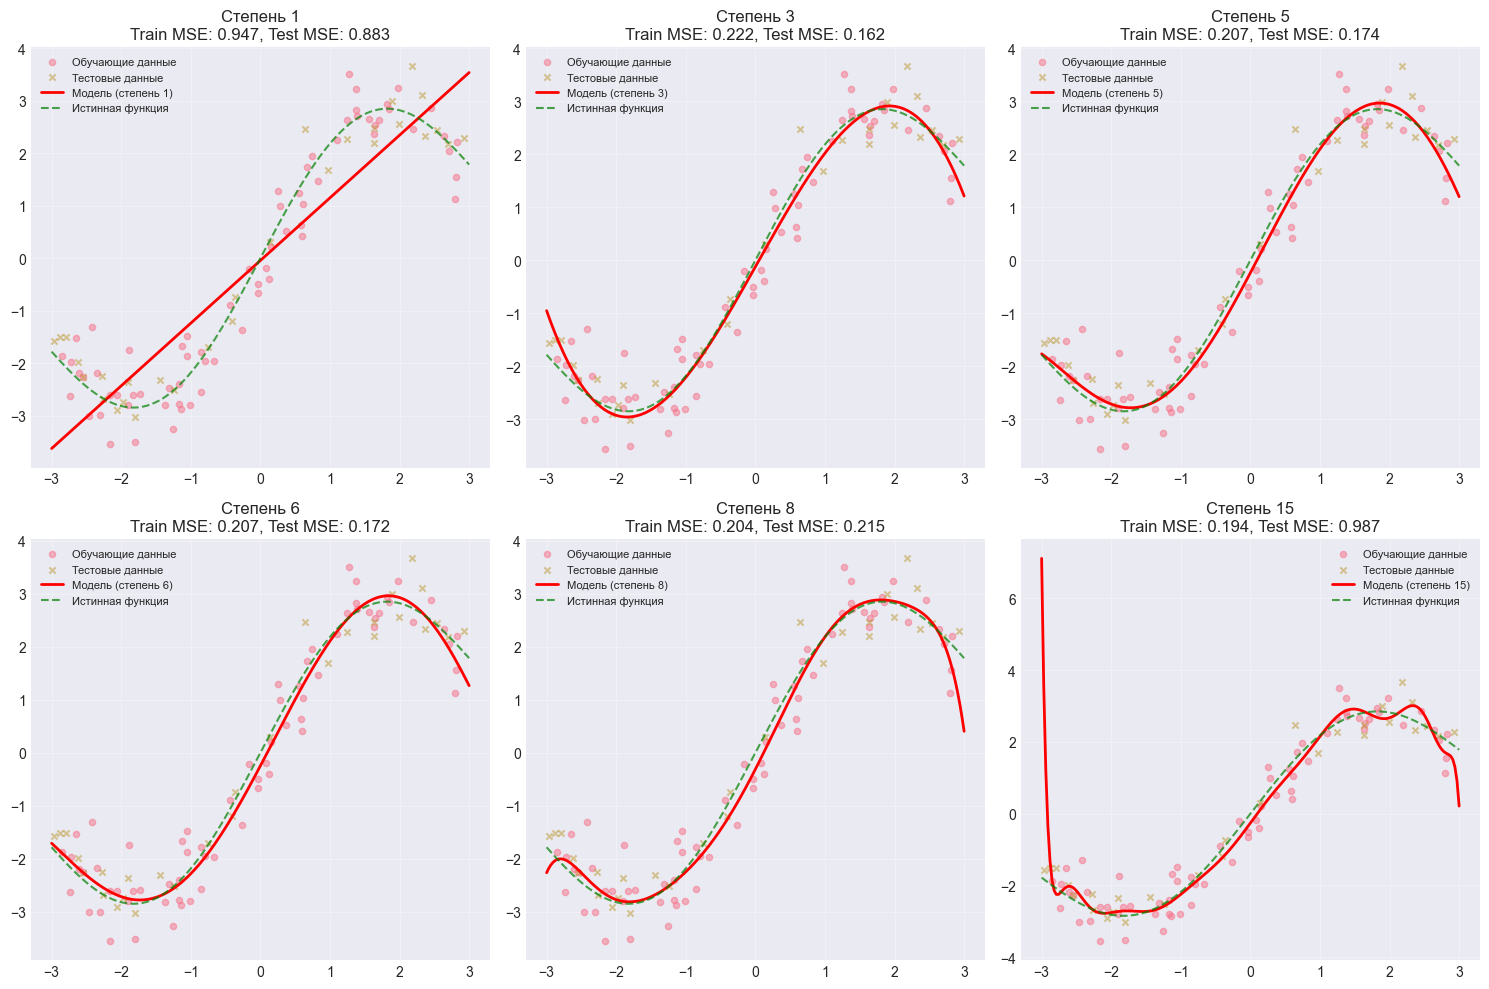


Вывод:
Оптимальная степень: 3
При степени 15: Train MSE = 0.1939, Test MSE = 0.9872
Модель идеально подстроилась под обучающие данные, но потеряла способность к обобщению - это переобучение


In [9]:
np.random.seed(42)
n_samples = 100
X = np.random.uniform(-3, 3, n_samples).reshape(-1, 1)
y_true = 2 * np.sin(X).ravel() + 0.5 * X.ravel()
y = y_true + np.random.normal(0, 0.5, n_samples)

# Разделяем на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Функция для создания полиномиальных признаков
def poly_features(X, degree):
    result = X.copy()
    for d in range(2, degree + 1):
        result = np.hstack([result, X**d])
    return result

# Обучаем модели разной сложности
degrees = [1, 2, 3, 4, 5, 6, 8, 10, 15]
train_errors = []
test_errors = []

for d in degrees:
    X_train_poly = poly_features(X_train, d)
    X_test_poly = poly_features(X_test, d)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    train_pred = model.predict(X_train_poly)
    test_pred = model.predict(X_test_poly)
    
    train_errors.append(mean_squared_error(y_train, train_pred))
    test_errors.append(mean_squared_error(y_test, test_pred))
    
    print(f"Степень {d:2d}: Train MSE = {train_errors[-1]:.4f}, Test MSE = {test_errors[-1]:.4f}")

# График ошибок
plt.figure(figsize=(10, 5))
plt.plot(degrees, train_errors, 'bo-', label='Ошибка на обучении', linewidth=2)
plt.plot(degrees, test_errors, 'ro-', label='Ошибка на тесте', linewidth=2)
plt.xlabel('Степень полинома')
plt.ylabel('MSE')
plt.title('Переобучение: ошибка на тесте растет после определенной степени')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Визуализация предсказаний для некоторых степеней
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
plot_degrees = [1, 3, 5, 6, 8, 15]

for idx, d in enumerate(plot_degrees):
    X_train_poly = poly_features(X_train, d)
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    X_plot = np.linspace(-3, 3, 200).reshape(-1, 1)
    X_plot_poly = poly_features(X_plot, d)
    y_plot_pred = model.predict(X_plot_poly)
    
    axes[idx//3, idx%3].scatter(X_train, y_train, alpha=0.5, label='Обучающие данные', s=20)
    axes[idx//3, idx%3].scatter(X_test, y_test, alpha=0.5, label='Тестовые данные', s=20, marker='x')
    axes[idx//3, idx%3].plot(X_plot, y_plot_pred, 'r-', label=f'Модель (степень {d})', linewidth=2)
    axes[idx//3, idx%3].plot(X_plot, 2*np.sin(X_plot).ravel() + 0.5*X_plot.ravel(), 'g--', label='Истинная функция', alpha=0.7)
    axes[idx//3, idx%3].set_title(f'Степень {d}\nTrain MSE: {train_errors[degrees.index(d)]:.3f}, Test MSE: {test_errors[degrees.index(d)]:.3f}')
    axes[idx//3, idx%3].legend(fontsize=8)
    axes[idx//3, idx%3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nВывод:")
print(f"Оптимальная степень: {degrees[np.argmin(test_errors)]}")
print(f"При степени 15: Train MSE = {train_errors[-1]:.4f}, Test MSE = {test_errors[-1]:.4f}")
print("Модель идеально подстроилась под обучающие данные, но потеряла способность к обобщению - это переобучение")